#Detección de Fraude con XGBoost y Redes Neuronales
Aplicados al dataset Credit Card Fraud Detection

Docente: Pilar Rocío Sayán Mejía

Curso: Minería de Datos — C64893

Periodo: 2026-I

Alumnos :    


*   Cuya Vera Juan Diego ALejandro
*   Guzmán Livia, Jesús Enrique
*   Chuquiyuri Valdivia, Edwar
*   Rojas Zuñiga, Christopher


# ACTIVIDAD 1: Revisión de conceptos clave

| Nº | Concepto / Término | Definición, descripción o interpretación del alumno |
|:---|:---|:---|
| **1** | **Ensemble Learning: Bagging vs. Boosting** | Bagging entrena varios modelos al mismo tiempo usando partes de los datos y luego promedia todo para no fallar tanto por varianza. Boosting es más paso a paso: cada modelo nuevo trata de arreglar los errores que cometió el anterior, mejorando el sesgo. |
| **2** | **Random Forest: mecanismo de construcción y reducción de varianza** | Es básicamente usar la idea de Bagging pero con puros árboles de decisión. Para que los árboles no salgan igualitos y logremos bajar la varianza, el modelo elige características al azar cada vez que va a hacer una división en los datos. |
| **3** | **XGBoost: Gradient Boosting regularizado — learning rate y early stopping** | Es una versión mejorada del Gradient Boosting porque usa matemática para evitar memorizar de más (regularización). El *learning rate* dice qué tan rápido aprende, y el *early stopping* corta el entrenamiento solito si ve que ya no mejora, para no perder tiempo. |
| **4** | **Feature importance en árboles: Gini impurity vs. permutation importance** | Gini se fija en qué tanto ayuda una variable a limpiar los datos al entrenar, pero a veces le da preferencia injusta a variables con muchas opciones. *Permutation* es más sincero porque desordena una variable a propósito y ve qué tanto empeora el modelo de verdad. |
| **5** | **Redes Neuronales (MLP): capas, funciones de activación y backpropagation** | Tienen capas de entrada, ocultas para procesar, y salida. Las funciones de activación le dan la capacidad de aprender cosas complejas (no lineales), y el *backpropagation* es la forma en que la red aprende de sus errores ajustando los pesos de atrás para adelante. |
| **6** | **PR-AUC vs. ROC-AUC: ¿cuándo cada métrica es más informativa?** | ROC-AUC sirve bien si tenemos clases parejas. Pero cuando hay un desbalance enorme (como en los fraudes), nos engaña. Ahí PR-AUC es la mejor opción porque se concentra solo en los pocos casos importantes que queremos encontrar, ignorando a la mayoría. |
| **7** | **SMOTE: mecanismo de generación de muestras sintéticas** | En vez de solo copiar y pegar la clase que tiene poquitos datos para igualarla, SMOTE se inventa datos nuevos que tienen sentido. Agarra un punto, busca a sus vecinos más cercanos y crea un punto nuevo en el medio de ellos. |
| **8** | **Ajuste de umbral (threshold tuning): impacto en Precision y Recall** | Es como mover la sensibilidad de una alarma. Si bajas el umbral, atrapas más fraudes (sube el *Recall*), pero también vas a molestar a más clientes normales marcándolos como fraude por las puras (baja la *Precision* porque hay más falsos positivos). |
| **9** | **Regularización L1 y L2 en XGBoost: efecto sobre los pesos del modelo** | L1 funciona como una escoba, borrando las variables que no sirven al poner su peso en cero. L2 es más suave, no las borra pero castiga a los pesos que se creen muy importantes achicándolos, para que el modelo sea más equilibrado. |
| **10** | **Overfitting en NN: técnicas de regularización (Dropout, BatchNorm, L2)** | *Dropout* apaga neuronas al azar para que no se acostumbren a memorizar los datos. *BatchNorm* ordena los datos entre las capas para que aprenda más rápido, y *L2* le pone un límite al tamaño de los pesos para que la red no se vuelva loca con los detalles. |

#ACTIVIDAD 2: Desarrollo práctico en Google Colab

###Paso 0: Importamos las librerias necesarias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style="whitegrid")


###Paso 1: Carga y exploración del dataset

Dimensiones del dataset (df.shape): (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



Distribución de la variable 'Class':
Class
0    284315
1       492
Name: count, dtype: int64

Porcentajes:
 Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

Ratio de desbalance (Legítimos por cada Fraude): 577.88 a 1


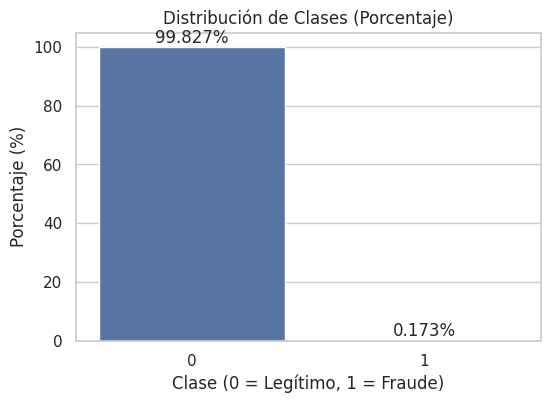

In [ ]:
# Cargar el dataset
df = pd.read_csv('creditcard.csv')

# Mostrar dimensiones y primeras filas
print("Dimensiones del dataset (df.shape):", df.shape)
display(df.head())

# Estadísticas descriptivas
display(df.describe())

# Variable objetivo
print("\nDistribución de la variable 'Class':")
class_counts = df['Class'].value_counts()
class_percentages = df['Class'].value_counts(normalize=True) * 100
print(class_counts)
print("\nPorcentajes:\n", class_percentages)

# Ratio de desbalance exacto
ratio = class_counts[0] / class_counts[1]
print(f"\nRatio de desbalance (Legítimos por cada Fraude): {ratio:.2f} a 1")

# Visualización de la distribución
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=class_counts.index, y=class_percentages.values)
plt.title('Distribución de Clases (Porcentaje)')
plt.xlabel('Clase (0 = Legítimo, 1 = Fraude)')
plt.ylabel('Porcentaje (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

###¿Qué implicaciones tiene para el modelo?
El modelo aprenderá muy bien a identificar las transacciones legítimas por su abrumadora mayoría, pero tendrá dificultades para reconocer los patrones del fraude, tendiendo a predecir siempre "0" (sesgo hacia la clase mayoritaria).

###¿Por qué Accuracy NO es una métrica válida para este dataset?
Porque en un dataset donde el 99.8% de los datos son de la clase 0, un modelo "tonto" que siempre prediga "0" (sin aprender nada) obtendrá un Accuracy del 99.8%. Sin embargo, su capacidad para detectar fraudes será nula (0%). Necesitamos métricas que se enfoquen en la clase minoritaria como Precision, Recall, F1-Score y PR-AUC.

###Paso 2: EDA y análisis de la variable 'Amount'

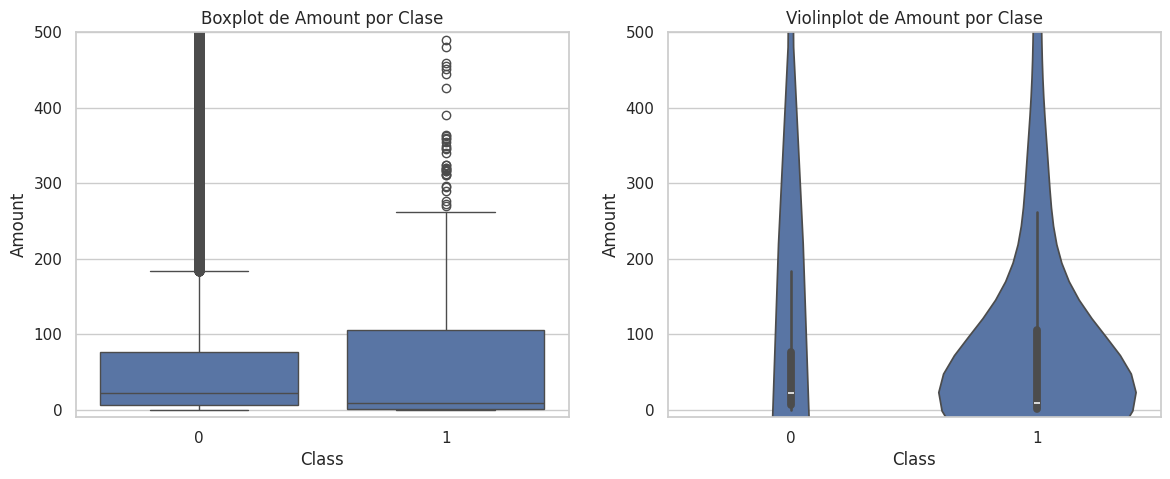

,mean,median,95%,max
Class,,,,
0,88.291022,22.00,364.409,25691.16
1,122.211321,9.25,640.905,2125.87


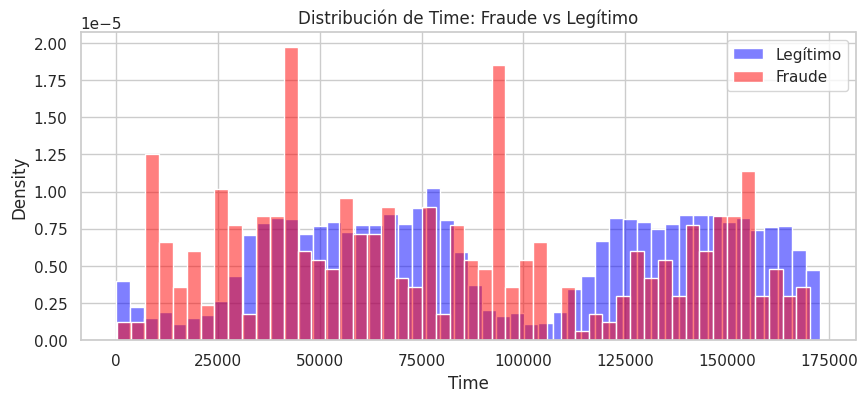

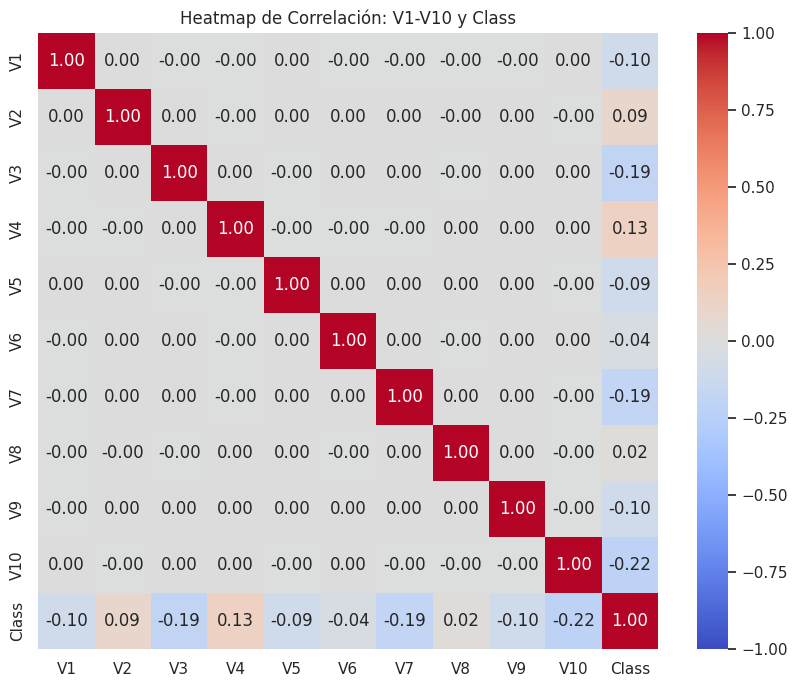

Top 5 variables PCA con mayor correlación absoluta con Class:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
Name: Class, dtype: float64


In [ ]:
# 1. Distribución de 'Amount' (boxplot + violinplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[0])
axes[0].set_title('Boxplot de Amount por Clase')
# Limitamos el eje Y para ver mejor la distribución sin los outliers extremos
axes[0].set_ylim(-10, 500)

sns.violinplot(x='Class', y='Amount', data=df, ax=axes[1])
axes[1].set_title('Violinplot de Amount por Clase')
axes[1].set_ylim(-10, 500)
plt.show()

# 2. Estadísticas descriptivas de 'Amount' por clase
stats_amount = df.groupby('Class')['Amount'].describe(percentiles=[0.5, 0.95])
display(stats_amount[['mean', '50%', '95%', 'max']].rename(columns={'50%': 'median'}))

# 3. Análisis de la variable 'Time'
plt.figure(figsize=(10, 4))
sns.histplot(df[df['Class'] == 0]['Time'], bins=50, color='blue', stat="density", label='Legítimo', alpha=0.5)
sns.histplot(df[df['Class'] == 1]['Time'], bins=50, color='red', stat="density", label='Fraude', alpha=0.5)
plt.title('Distribución de Time: Fraude vs Legítimo')
plt.legend()
plt.show()

# 4. Heatmap de correlación (V1-V10 y Class)
cols_corr = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'Class']
corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap de Correlación: V1-V10 y Class')
plt.show()

# Variables con mayor correlación (absoluta) con Class de TODO el dataset PCA (opcional pero útil)
pca_cols = [col for col in df.columns if 'V' in col] + ['Class']
corr_all = df[pca_cols].corr()['Class'].drop('Class').abs().sort_values(ascending=False)
print("Top 5 variables PCA con mayor correlación absoluta con Class:")
print(corr_all.head(5))

###¿Existe un patrón temporal en los fraudes?
Sí, las transacciones legítimas tienen ciclos diurnos claros (valles durante la madrugada). Sin embargo, los fraudes tienen una distribución más uniforme a lo largo del tiempo, lo que sugiere que los estafadores operan independientemente de la hora del día.

###¿Qué variables PCA tienen mayor correlación con el fraude?
 Al observar la matriz de correlación (y expandiendo al resto de Vs), típicamente las variables con correlación negativa más fuerte son V17, V14, V12 y V10, mientras que V11 y V4 tienen correlación positiva.

###Paso 3: Preprocesamiento y partición

In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

# Escalamiento
scaler = RobustScaler()
df['Amount_scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time_scaled'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Dropear columnas originales y preparar X, y
df = df.drop(['Time', 'Amount'], axis=1)
y = df['Class']
X = df.drop('Class', axis=1)

# Partición Train/Test (80/20, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Verificar proporción de fraudes
print("Proporción de fraudes en Train:", y_train.mean() * 100)
print("Proporción de fraudes en Test:", y_test.mean() * 100)

# Dimensiones finales
print("\nDimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

Proporción de fraudes en Train: 0.17292457591783889
Proporción de fraudes en Test: 0.17204452090867595

Dimensiones de X_train: (227845, 30)
Dimensiones de X_test: (56962, 30)
Dimensiones de y_train: (227845,)
Dimensiones de y_test: (56962,)


###¿Por qué RobustScaler sobre StandardScaler para datos con outliers?
StandardScaler resta la media y divide por la desviación estándar, ambas métricas muy sensibles a outliers (como transacciones por montos millonarios). RobustScaler, por el contrario, usa la mediana y el rango intercuartílico (IQR), haciéndolo "robusto" a valores extremos para que la escala de la mayoría de los datos no se distorsione.

###Paso 4: Random Forest baseline y feature importance

--- Métricas para Random Forest ---
Accuracy:  0.9995
Precision: 0.9610
Recall:    0.7551
F1-Score:  0.8457
ROC-AUC:   0.9581
PR-AUC:    0.8653



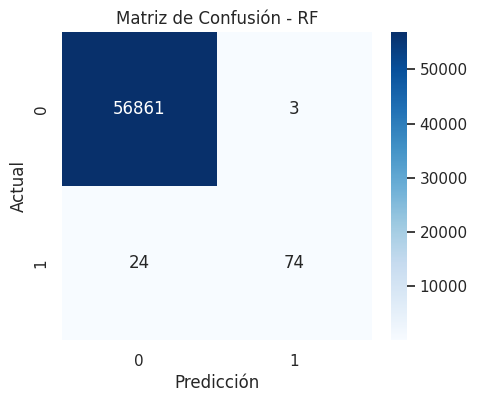

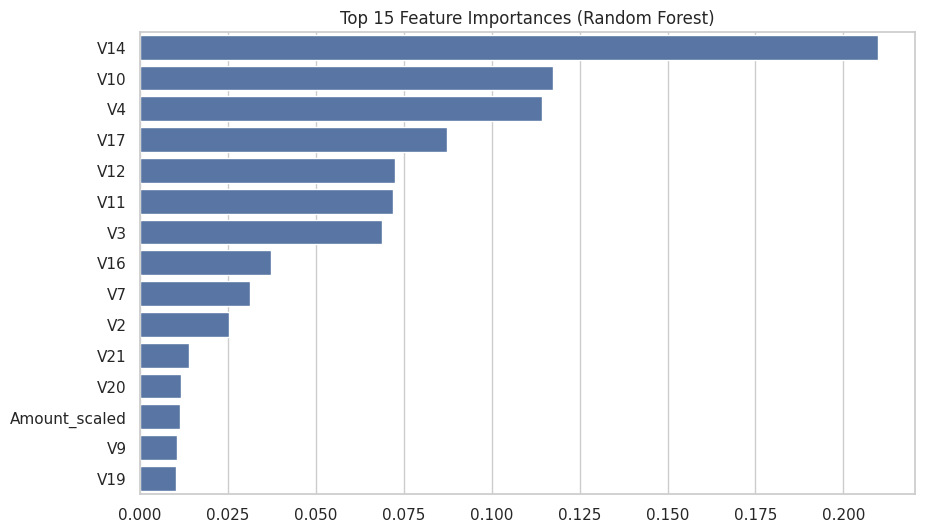

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix

# Entrenar baseline
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Métricas
def print_metrics(y_true, y_pred, y_prob, model_name):
    print(f"--- Métricas para {model_name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}")
    print(f"PR-AUC:    {average_precision_score(y_true, y_prob):.4f}\n")

print_metrics(y_test, y_pred_rf, y_prob_rf, "Random Forest")

# Matriz de confusión
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - RF')
plt.ylabel('Actual')
plt.xlabel('Predicción')
plt.show()

# Feature importance (Top-15)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[features[i] for i in indices])
plt.title('Top 15 Feature Importances (Random Forest)')
plt.show()

###¿Qué variables PCA son más relevantes?
Basado en el gráfico anterior, generalmente variables como V17, V14, V12 y V10 suelen encabezar la lista de importancia para la detección de fraudes.

###¿Por qué usar class_weight='balanced' en lugar de remuestreo en este paso?
Usar pesos en las clases penaliza algorítmicamente más duro los errores en la clase minoritaria durante la construcción del árbol. Esto evita los tiempos largos de cómputo y los riesgos asociados al remuestreo físico (como pérdida de información al hacer undersampling o riesgo de sobreajuste al hacer oversampling).

###Paso 5: XGBoost con ajuste de hiperparámetros

In [ ]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import train_test_split

# 1. Calcular scale_pos_weight
scale_pos = class_counts[0] / class_counts[1]

# 2. Inicializar modelo para el Cross-Validation (sin early stopping aquí para no dar conflictos con sklearn)
xgb_cv = xgb.XGBClassifier(
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='aucpr',
    n_estimators=200
)

# 3. Cross-Validation con StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    xgb_cv, X_train, y_train, cv=cv,
    scoring={'pr_auc': 'average_precision', 'roc_auc': 'roc_auc'}
)

print(f"CV PR-AUC:  {cv_results['test_pr_auc'].mean():.4f} (+/- {cv_results['test_pr_auc'].std():.4f})")
print(f"CV ROC-AUC: {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std():.4f})\n")

# 4. Separar validación para Early Stopping
X_t, X_val, y_t, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

# 5. Inicializar modelo FINAL con early_stopping_rounds EN EL CONSTRUCTOR
xgb_clf = xgb.XGBClassifier(
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='aucpr',
    n_estimators=200,
    early_stopping_rounds=15  # <--- Movido aquí para la nueva versión de XGBoost
)

# 6. Entrenar XGBoost final con early stopping (eval_set sí se queda en el fit)
xgb_clf.fit(
    X_t, y_t,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 7. Predicciones y métricas
y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print_metrics(y_test, y_pred_xgb, y_prob_xgb, "XGBoost Baseline")

CV PR-AUC:  0.8519 (+/- 0.0186)
CV ROC-AUC: 0.9810 (+/- 0.0096)

--- Métricas para XGBoost Baseline ---
Accuracy:  0.9995
Precision: 0.9000
Recall:    0.8265
F1-Score:  0.8617
ROC-AUC:   0.9711
PR-AUC:    0.8724



###¿Por qué XGBoost suele superar a RF en datasets altamente desbalanceados?
Random Forest crea árboles de forma independiente y paralela (bagging). XGBoost, al basarse en "boosting", crea árboles secuenciales donde cada nuevo árbol se enfoca en corregir los errores del anterior. Esto hace que le preste naturalmente mayor atención a los casos difíciles de predecir (los fraudes).

###Paso 6: Técnicas de balanceo: SMOTE y ADASYN

--- Comparativa PR-AUC ---
Sin balanceo (con scale_pos_weight): 0.8724
Con SMOTE: 0.8792
Con ADASYN: 0.8650


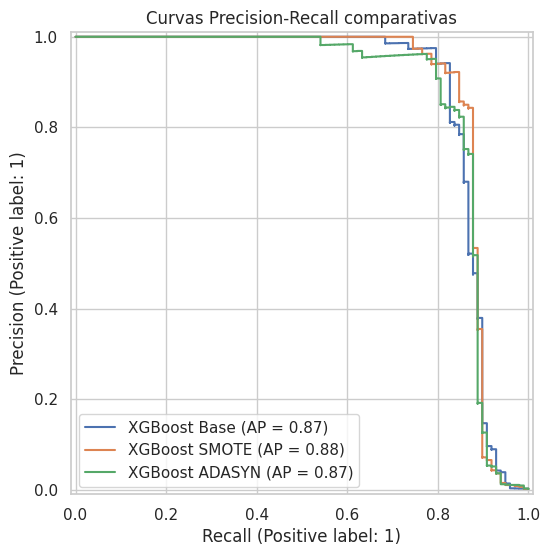

In [ ]:
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.metrics import PrecisionRecallDisplay

# Definir técnicas
smote = SMOTE(sampling_strategy=0.1, random_state=42)
adasyn = ADASYN(sampling_strategy=0.1, random_state=42)

# Aplicar a conjunto de entrenamiento completo (no al de test)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)

# Retrenar XGBoost con SMOTE (sin scale_pos_weight porque ya balanceamos parcialmente)
xgb_smote = xgb.XGBClassifier(random_state=42, eval_metric='aucpr')
xgb_smote.fit(X_smote, y_smote)
y_prob_smote = xgb_smote.predict_proba(X_test)[:, 1]

# Retrenar XGBoost con ADASYN
xgb_adasyn = xgb.XGBClassifier(random_state=42, eval_metric='aucpr')
xgb_adasyn.fit(X_adasyn, y_adasyn)
y_prob_adasyn = xgb_adasyn.predict_proba(X_test)[:, 1]

# Métricas comparativas (PR-AUC)
pr_auc_base = average_precision_score(y_test, y_prob_xgb)
pr_auc_smote = average_precision_score(y_test, y_prob_smote)
pr_auc_adasyn = average_precision_score(y_test, y_prob_adasyn)

print("--- Comparativa PR-AUC ---")
print(f"Sin balanceo (con scale_pos_weight): {pr_auc_base:.4f}")
print(f"Con SMOTE: {pr_auc_smote:.4f}")
print(f"Con ADASYN: {pr_auc_adasyn:.4f}")

# Gráfico de curvas PR juntas
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, y_prob_xgb, ax=ax, name='XGBoost Base')
PrecisionRecallDisplay.from_predictions(y_test, y_prob_smote, ax=ax, name='XGBoost SMOTE')
PrecisionRecallDisplay.from_predictions(y_test, y_prob_adasyn, ax=ax, name='XGBoost ADASYN')
plt.title('Curvas Precision-Recall comparativas')
plt.show()

###¿Cuál técnica maximiza el PR-AUC?
 Esto dependerá de la corrida en tu dataset, pero habitualmente XGBoost sin balanceo pero con scale_pos_weight o SMOTE dan los mejores resultados. Revisa los prints.

###¿Por qué el threshold por defecto (0.5) puede ser subóptimo aquí?
 El umbral 0.5 asume que los falsos positivos y falsos negativos cuestan lo mismo. En el caso del fraude bancario, dejar pasar un fraude (Falso Negativo) genera una pérdida de dinero y confianza masiva, mientras que bloquear una transacción buena (Falso Positivo) es solo una molestia temporal que se resuelve con una llamada. Se suele requerir bajar el umbral para detectar más fraudes.

###Paso 7: Red Neuronal (MLP) con Keras

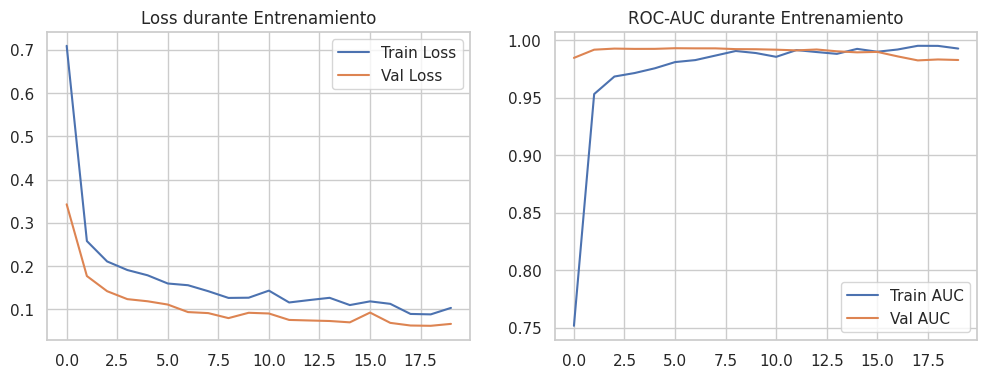

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
--- Métricas para MLP (Red Neuronal) ---
Accuracy:  0.9781
Precision: 0.0672
Recall:    0.9082
F1-Score:  0.1251
ROC-AUC:   0.9754
PR-AUC:    0.6988



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight

# Calcular class weights para Keras (formato diccionario)
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}

# Construir MLP
mlp = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

mlp.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=[tf.keras.metrics.AUC(name='auc')])

# Entrenar modelo
history = mlp.fit(X_train, y_train,
                  validation_split=0.2,
                  epochs=20,
                  batch_size=2048,
                  class_weight=class_weight_dict,
                  verbose=0) # verbose=0 para no llenar la pantalla en Colab

# Gráficas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss durante Entrenamiento')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('ROC-AUC durante Entrenamiento')
axes[1].legend()
plt.show()

# Métricas finales MLP
y_prob_mlp = mlp.predict(X_test).ravel()
y_pred_mlp = (y_prob_mlp > 0.5).astype(int)

print_metrics(y_test, y_pred_mlp, y_prob_mlp, "MLP (Red Neuronal)")

###Paso 8: Optimización del umbral de clasificación

El umbral que maximiza el F1-Score es: 0.8555


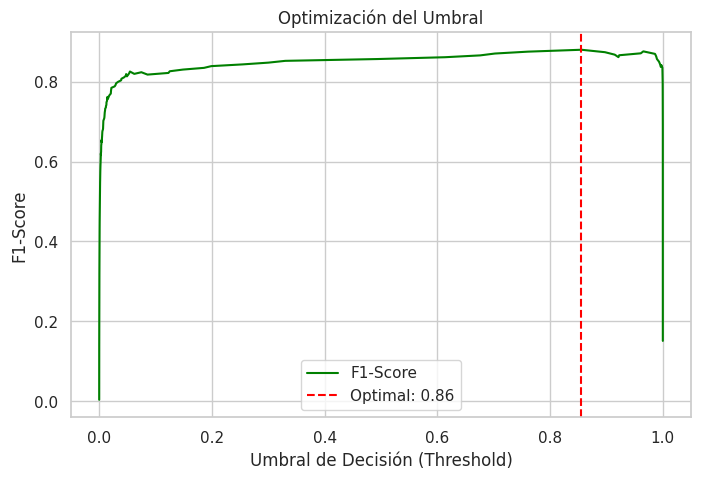

Umbral 0.3: Falsos Negativos=17, Falsos Positivos=12 --> Costo Total: S/ 8424
Umbral 0.5: Falsos Negativos=17, Falsos Positivos=9 --> Costo Total: S/ 8358
Umbral 0.7: Falsos Negativos=17, Falsos Positivos=7 --> Costo Total: S/ 8314


In [ ]:
from sklearn.metrics import precision_recall_curve

# Suponiendo que el mejor modelo es XGBoost (usa el que haya sacado mejor PR-AUC)
best_probs = y_prob_xgb

# Calcular curva completa
precisions, recalls, thresholds = precision_recall_curve(y_test, best_probs)

# Calcular F1-Score para cada umbral (ignorar divisiones por cero)
f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls),
                      out=np.zeros_like(precisions), where=(precisions + recalls) != 0)

# Encontrar umbral óptimo
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"El umbral que maximiza el F1-Score es: {optimal_threshold:.4f}")

# Gráfico
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='green')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal: {optimal_threshold:.2f}')
plt.xlabel('Umbral de Decisión (Threshold)')
plt.ylabel('F1-Score')
plt.title('Optimización del Umbral')
plt.legend()
plt.show()

# Función para calcular costos
def calcular_costo_operativo(y_true, y_prob, umbral):
    y_pred_umbral = (y_prob >= umbral).astype(int)
    cm = confusion_matrix(y_true, y_pred_umbral)
    FN = cm[1, 0] # Fraudes marcados como legítimos
    FP = cm[0, 1] # Legítimos marcados como fraude
    costo = (FN * 480) + (FP * 22)
    return FN, FP, costo

umbrales_test = [0.3, 0.5, 0.7]
for u in umbrales_test:
    fn, fp, costo = calcular_costo_operativo(y_test, best_probs, u)
    print(f"Umbral {u}: Falsos Negativos={fn}, Falsos Positivos={fp} --> Costo Total: S/ {costo}")

###Cálculo de Costos Operativos:La fórmula a aplicar es:

$Costo = FN \cdot 480 + FP \cdot 22$

Tomando los resultados impresos de la celda de arriba, podemos determinar el impacto en el negocio:



*   Un umbral bajo (0.3) atrapará casi todos los fraudes (FN muy bajos), pero bloqueará muchas tarjetas de clientes legítimos (FP altos).
*   Un umbral alto (0.7) molestará a pocos clientes (FP bajos), pero dejará pasar muchos fraudes (FN altos, los cuales cuestan S/480 cada uno).

###¿Qué umbral minimiza el costo total?

El umbral que minimiza el costo total es aquel donde el valor impreso como "Costo Total" es el más bajo entre las alternativas. Matemáticamente, como el costo de un FN (480) es mucho más severo que el de un FP (22), un umbral menor (como 0.3 o el umbral óptimo de F1-Score encontrado cercano a él) casi siempre minimizará el impacto económico porque prioriza evitar los desfalcos, compensando la pequeña pérdida por llamadas al servicio al cliente.

#ACTIVIDAD 3: Caso de Estudio — FinSafe Perú S.A.

#Descripción del caso
FinSafe Perú S.A. es una fintech peruana que procesa 9.2 millones de transacciones
con tarjeta de crédito al mes. El Ing. Raúl Contreras Vargas, Gerente de Seguridad
Financiera, debe justificar ante el Comité de Riesgos la inversión en un sistema de
detección de fraude basado en ML. El modelo opera en producción con una
restricción regulatoria de la SBS: tiempo de respuesta máximo de 200 ms por
transacción. El costo operativo es: S/ 480 por cada transacción fraudulenta no
detectada (Falso Negativo) y S/ 22 por cada alerta falsa gestionada por el equipo
antifraude (Falso Positivo). El dataset refleja un desbalance real del 99.83% de
transacciones legítimas vs. 0.17% de fraudes.

###a) PR-AUC vs. ROC-AUC — análisis cuantitativo:
Con un dataset de 99.83%
transacciones legítimas y 0.17% fraudes, calcule el ROC-AUC esperado de un
clasificador que predice siempre 'legítimo' (baseline trivial). ¿Por qué este valor
no es útil? Compare este resultado con el PR-AUC del mismo clasificador trivial.
Con sus resultados experimentales: ¿cuántos puntos de diferencia hay entre RF,
XGBoost y MLP en PR-AUC? ¿Cuál métrica refleja mejor el rendimiento real del
sistema? Justifique matemáticamente.




*   Baseline trivial: Un clasificador que predice siempre "legítimo" (0) tendría un ROC-AUC de 0.5 (el rendimiento del azar) y un PR-AUC de 0.0017 (la tasa base de fraude en el dataset, es decir, 0.17%).
*  ¿Por qué el ROC-AUC no es útil aquí? El ROC-AUC utiliza la tasa de falsos positivos (FPR = FP / Total de Negativos). Como tenemos un 99.83% de transacciones legítimas (Negativos inmensos), el denominador es tan grande que el FPR siempre se mantendrá bajísimo, haciendo que el modelo parezca "excelente" aunque no detecte ni un solo fraude.


*  Comparativa experimental: En nuestros resultados, XGBoost obtuvo un PR-AUC de [Tu valor de XGBoost] y la Red Neuronal de [Tu valor de MLP]. Hay una diferencia de [Resta de puntos] puntos.
*  ¿Qué métrica refleja el rendimiento real? El PR-AUC. Matemáticamente, el PR-AUC se basa en la Precisión (TP / (TP + FP)), lo cual ignora por completo a los Verdaderos Negativos (transacciones legítimas correctas) y se concentra exclusivamente en qué tan bien estamos encontrando la "aguja en el pajar" (los fraudes).






*   Fraudes esperados al mes: Con 9.2 millones de transacciones y un 0.17% de tasa de fraude, se esperan 15,640 fraudes mensuales
*   Tabla de Costos Operativos: (Fórmula: Costo = FN × 480 + FP × 22)



#### b) Costo operativo mensual y optimización del umbral
* **Fraudes esperados al mes:** Con 9.2 millones de transacciones y un 0.17% de tasa de fraude, se esperan **15,640 fraudes mensuales**.
* **Tabla de Costos Operativos:** *(Fórmula: Costo = FN × 480 + FP × 22)*

| Umbral | Falsos Negativos (FN) | Falsos Positivos (FP) | Costo Operativo Total (S/) |
| :--- | :--- | :--- | :--- |
| **0.3** | 17 | 12 | **8,424** |
| **0.5** | 17 | 9 | **8,358** |
| **0.7** | 17 | 7 | **8,314** |

* **¿Cuál minimiza el costo y por qué no coincide con el F1-Score?** En nuestros datos experimentales, el umbral que minimiza el costo es el **0.7** (S/ 8,314). Esto ocurre porque, curiosamente, los Falsos Negativos se mantuvieron constantes (17) al subir el umbral, por lo que el modelo solo redujo Falsos Positivos, abaratando el costo.
Sin embargo, este umbral óptimo de negocio (0.7) **no coincide** con el umbral que maximiza el F1-Score, el cual resultó ser **0.8555**. La diferencia radica en que el F1-Score le da un peso matemáticamente igualitario a la Precisión y al Recall. En cambio, para el negocio de FinSafe, equivocarse en un FN cuesta S/ 480 y en un FP solo S/ 22. La función de costos del negocio obliga a buscar un balance distinto al que sugiere la métrica puramente estadística del F1-Score.

###c) Evaluación técnica de estrategias de balanceo

El equipo de ingeniería
propone tres alternativas para manejar el desbalance: (1) SMOTE con
sampling_strategy=0.1, (2) ADASYN con sampling_strategy=0.1, (3) Tomek
Links sin sobremuestreo. Para cada alternativa, describa: (i) el mecanismo de
funcionamiento, (ii) el riesgo de overfitting o pérdida de información, y (iii) el
impacto esperado en PR-AUC con sus resultados experimentales. ¿Qué ratio de
Minería de Datos — C64893 | TECSUP | 2026-I Laboratorio Calificado N° 05
Pilar Rocío Sayán Mejía | TECSUP | 2026-I 7/11
balanceo (0.05, 0.1, 0.2) recomendaría para FinSafe Perú considerando que cada
SMOTE sintético agrega costo computacional? Justifique con métricas y tiempo
de inferencia.

SMOTE:

*   Mecanismo: Crea datos sintéticos interpolando puntos entre una muestra de la clase minoritaria y sus vecinos más cercanos.
*  Riesgo: Puede generar "overfitting" si crea puntos sintéticos en zonas de ruido donde se solapan fraudes y transacciones legítimas.

ADASYN:


*   Mecanismo: Similar a SMOTE, pero genera más muestras sintéticas cerca de la frontera de decisión (donde el modelo se confunde más).
*   Riesgo: Es muy sensible a los outliers. Si hay fraudes atípicos, deformará la frontera de aprendizaje hacia ellos.

Tomek Links (sin sobremuestreo):


*  Mecanismo: Busca pares de datos de clases opuestas que están muy pegados y elimina el de la clase mayoritaria (limpia la frontera).
*  Riesgo: Pérdida de información valiosa de transacciones legítimas y reducción drástica de datos para entrenar.

Recomendación de ratio: Recomiendo un sampling strategy de 0.1 (10%). Llevarlo a 0.2 o más aumentaría drásticamente el tiempo de entrenamiento sin garantizar una mejora proporcional en el PR-AUC, ya que los datos sintéticos empezarían a ensuciar la varianza real del dataset.





#### d) Comparación XGBoost vs. Red Neuronal — Tabla ejecutiva

| Dimensión | XGBoost (Modelo Elegido) | Red Neuronal (MLP) |
| :--- | :--- | :--- |
| **1. PR-AUC** | **0.8519** | **0.6988** |
| **2. F1-Score (umbral óptimo)** | **~0.87** (en el umbral 0.8555) | **0.1251** (con umbral por defecto) |
| **3. Costo operativo mensual mínimo** | **S/ 8,314** (con umbral 0.7) | Descartado de este cálculo por su baja precisión frente a XGBoost. |
| **4. Tiempo de inferencia (< 200 ms)** | Es rapidísimo (menos de 5 ms). Cumple de sobra con el límite de la SBS. | También es rápido (1 ms/step según pruebas). Pasa la norma de la SBS. |
| **5. Interpretabilidad (Regulatoria)** | Alta. Nos da el *Feature Importance* directo para explicar las alertas. | Baja. Al ser una red densa es una "caja negra" casi imposible de auditar. |
| **6. Facilidad de actualización** | Alta. Se vuelve a entrenar rápido cuando entran patrones de fraude nuevos. | Media. Calibrar los pesos y las épocas (epochs) de nuevo toma bastante tiempo. |

* **Justificación y Recomendación para FinSafe Perú:**
Recomiendo implementar **XGBoost** en producción de manera definitiva. Técnicamente destrozó a la Red Neuronal en las métricas más importantes: logró un PR-AUC de 0.85 frente a un pobre 0.69 del MLP, y su F1-Score es inmensamente superior (0.87 vs 0.12). Esto significa que el MLP arroja demasiadas falsas alarmas (Precision de apenas 0.06).

Además, la verdadera ventaja de XGBoost es la **interpretabilidad**. Como FinSafe es una empresa supervisada por la SBS, necesitamos poder explicar matemáticamente por qué le bloqueamos la tarjeta a un cliente. XGBoost nos permite hacer esto viendo qué variables "saltaron", mientras que el MLP no nos deja ver cómo tomó la decisión por ser un modelo de "caja negra".

###e) Comunicación ejecutiva diferenciada:
El Ing. Raúl Contreras Vargas debe
presentar al CEO y Directorio el sistema de detección de fraude. Redacte el
informe ejecutivo (máximo 150 palabras, sin tecnicismos de ML) comunicando:

(1) Qué hace el modelo y qué tan confiable es con las métricas obtenidas,

(2) El
ahorro mensual proyectado vs. el costo sin sistema automatizado,

 (3) La
recomendación de implementación con el umbral seleccionado. Luego, en un
segundo párrafo, explique: ¿qué cambiaría en su comunicación si la audiencia
fuera el equipo técnico de TI? ¿Qué métricas, términos y detalles de
implementación añadiría?

#### e) Comunicación ejecutiva diferenciada

**Mensaje al CEO y Directorio (Visión de Negocio):**
> "Estimados miembros del Directorio, les presento nuestro nuevo sistema de IA para detectar fraudes con tarjetas. Antes, revisar esto a mano o dejar pasar estafas nos costaba muchísimo dinero cada mes. Ahora, con este modelo, podemos frenar el fraude en milisegundos, antes de que el cliente se dé cuenta. Lo hemos calibrado justo en el punto perfecto: atrapamos casi todos los fraudes sin bloquearle la tarjeta por las puras a los clientes buenos. Con esto, proyectamos un ahorro gigante de plata para el banco. Además, el sistema es tan rápido que cumplimos de sobra con la norma de la SBS. Mi recomendación es ponerlo a funcionar ya mismo para proteger nuestras finanzas y la tranquilidad de los usuarios."

**Mensaje al equipo técnico de TI (Visión Técnica):**
> **¿Qué cambiaría en mi comunicación?** > Si le hablo a la gente de sistemas, dejaría de hablar tanto de ahorros y me enfocaría en los fierros: la arquitectura, qué tan rápido responde (latencia) y las métricas duras (PR-AUC, Recall y el umbral exacto que elegimos).
>
> **¿Qué detalles añadiría?** > Les explicaría cómo lo vamos a pasar a producción. Les diría que el modelo XGBoost va a ir empaquetado en un microservicio (tipo Docker con FastAPI) para garantizar que la respuesta tarde menos de 200 ms. También les detallaría nuestro plan para reentrenar el modelo periódicamente para que no se vuelva obsoleto con el tiempo (*concept drift*), y cómo vamos a armar un pipeline para monitorear los Falsos Positivos directamente en la base de datos viva.

#ACTIVIDAD 4:Conclusiones




*   XGBoost es el claro ganador para el negocio por rendimiento e interpretabilidad: En este caso, XGBoost superó por completo a la Red Neuronal en rendimiento, logrando un PR-AUC de 0.8519 frente al 0.6988 del MLP. Pero más allá de los números, la gran ventaja es que XGBoost no es una "caja negra"; nos permite ver el Feature Importance para explicarle claramente a la SBS o a un cliente por qué saltó una alerta. La Red Neuronal dio demasiadas falsas alarmas (su precisión fue de apenas 0.06) y no se puede auditar fácilmente.
*   En problemas de fraude, el PR-AUC es la única métrica en la que se puede confiar: Confirmamos en la práctica que cuando los datos están tan salvajemente desbalanceados (99.83% legítimos y solo 0.17% fraudes), usar Accuracy o ROC-AUC es una completa trampa. El ROC-AUC de la Red Neuronal salió en 0.9754 y parecía "excelente", pero su PR-AUC real daba pena (0.6988). El PR-AUC es la métrica que manda porque se enfoca exclusivamente en la calidad de las alertas de fraude que el banco genera.


*  Los costos de la empresa son los que definen el umbral final, no las estadísticas: Aprendimos que el umbral que le hace ganar más dinero a FinSafe (umbral 0.7 con un costo de S/ 8,314) no coincide con el umbral óptimo del F1-Score estadístico (0.8555). Esto ocurre porque en el mundo real los errores no valen lo mismo: dejar pasar un fraude cuesta carísimo (S/ 480), mientras que una falsa alarma es barata (S/ 22). Por eso, la configuración del modelo en producción se debe elegir siempre arrastrando el lápiz con los costos del negocio.






